## **1. Data Preparation**

### **Pengumpulan dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from urllib.parse import urlparse
from collections import Counter

# Mendefinisikan path file
file_dataset = r"D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\dataset_phishing.csv"

# Memuat dataset
df = pd.read_csv(file_dataset)

### **Analisis dataset**

In [2]:
# 1. Informasi Dasar Dataset
dtype_summary = df.dtypes.reset_index()
dtype_summary.columns = ['Nama Kolom', 'Tipe Data']

# Menampilkan jumlah baris dan kolom
print(f"Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom.\n")

with pd.option_context('display.max_rows', None):
    display(dtype_summary.style.set_properties(**{'text-align': 'left'})
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))

Dataset memiliki 11430 baris dan 89 kolom.



,Nama Kolom,Tipe Data
0,url,object
1,length_url,int64
2,length_hostname,int64
3,ip,int64
4,nb_dots,int64
5,nb_hyphens,int64
6,nb_at,int64
7,nb_qm,int64
8,nb_and,int64
9,nb_or,int64


In [3]:
# 2. Pengecekan Kualitas Data (Data Cleaning)
# Mengecek Missing Values (Data yang kosong)
print("--- Mengecek Missing Values ---")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Tidak ada data yang kosong di seluruh 89 kolom.")
else:
    print("Kolom dengan data kosong:")
    print(missing[missing > 0])

--- Mengecek Missing Values ---
Tidak ada data yang kosong di seluruh 89 kolom.


In [4]:
# Mengecek Baris Duplikat pada Kolom Url

nama_kolom = 'url'

# Mencari semua baris yang memiliki URL duplikat
# keep=False artinya semua baris yang sama akan ditampilkan (bukan cuma salah satu)
df_duplikat_url = df[df[nama_kolom].duplicated(keep=False)]

# 3. Menampilkan hasil analisis
print(f"--- Mengecek Duplikat Kolom: {nama_kolom} ---")
print(f"Total baris yang terindikasi duplikat: {len(df_duplikat_url)}")

if len(df_duplikat_url) > 0:
    print("\n--- Daftar URL yang duplikat dan jumlah kemunculannya ---")
    print(df_duplikat_url[nama_kolom].value_counts())
    
    # Menampilkan 5 contoh data duplikat pertama (beserta kolom lainnya)
    print("\n--- Pratinjau Data Duplikat ---")
    display(df_duplikat_url.head(5))
else:
    print("\nSelamat! Tidak ada baris duplikat pada kolom URL.")

--- Mengecek Duplikat Kolom: url ---
Total baris yang terindikasi duplikat: 2

--- Daftar URL yang duplikat dan jumlah kemunculannya ---
url
http://e710z0ear.du.r.appspot.com/c:/users/user/downlo    2
Name: count, dtype: int64

--- Pratinjau Data Duplikat ---


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
6035,http://e710z0ear.du.r.appspot.com/c:/users/use...,62,26,0,4,0,0,0,0,0,...,1,1,0,217,5627,0,0,1,5,phishing
11305,http://e710z0ear.du.r.appspot.com/c:/users/use...,54,26,0,4,0,0,0,0,0,...,1,1,0,230,5614,0,0,1,5,phishing



--- Distribusi Kelas (status) ---
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19484\399458916.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


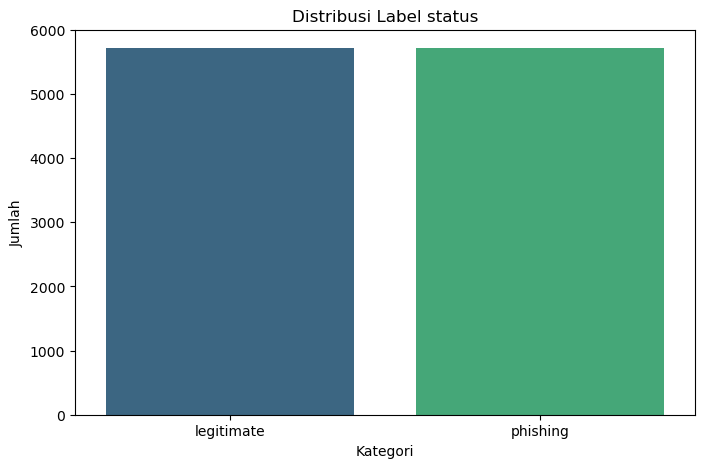

In [5]:
# Analisis Target (Label)
# Asumsi kolom target bernama 'status' atau 'label'. 
target_col = 'status'
if target_col in df.columns:
    print(f"\n--- Distribusi Kelas ({target_col}) ---")
    print(df[target_col].value_counts())
    
    # Visualisasi Distribusi Target
    plt.figure(figsize=(8, 5))
    sns.countplot(x=target_col, data=df, palette='viridis')
    plt.title(f'Distribusi Label {target_col}')
    plt.ylabel('Jumlah')
    plt.xlabel('Kategori')
    plt.show()
else:
    print(f"\nKolom '{target_col}' tidak ditemukan. Cek kembali nama kolom target.")


--- Heatmap Korelasi ---


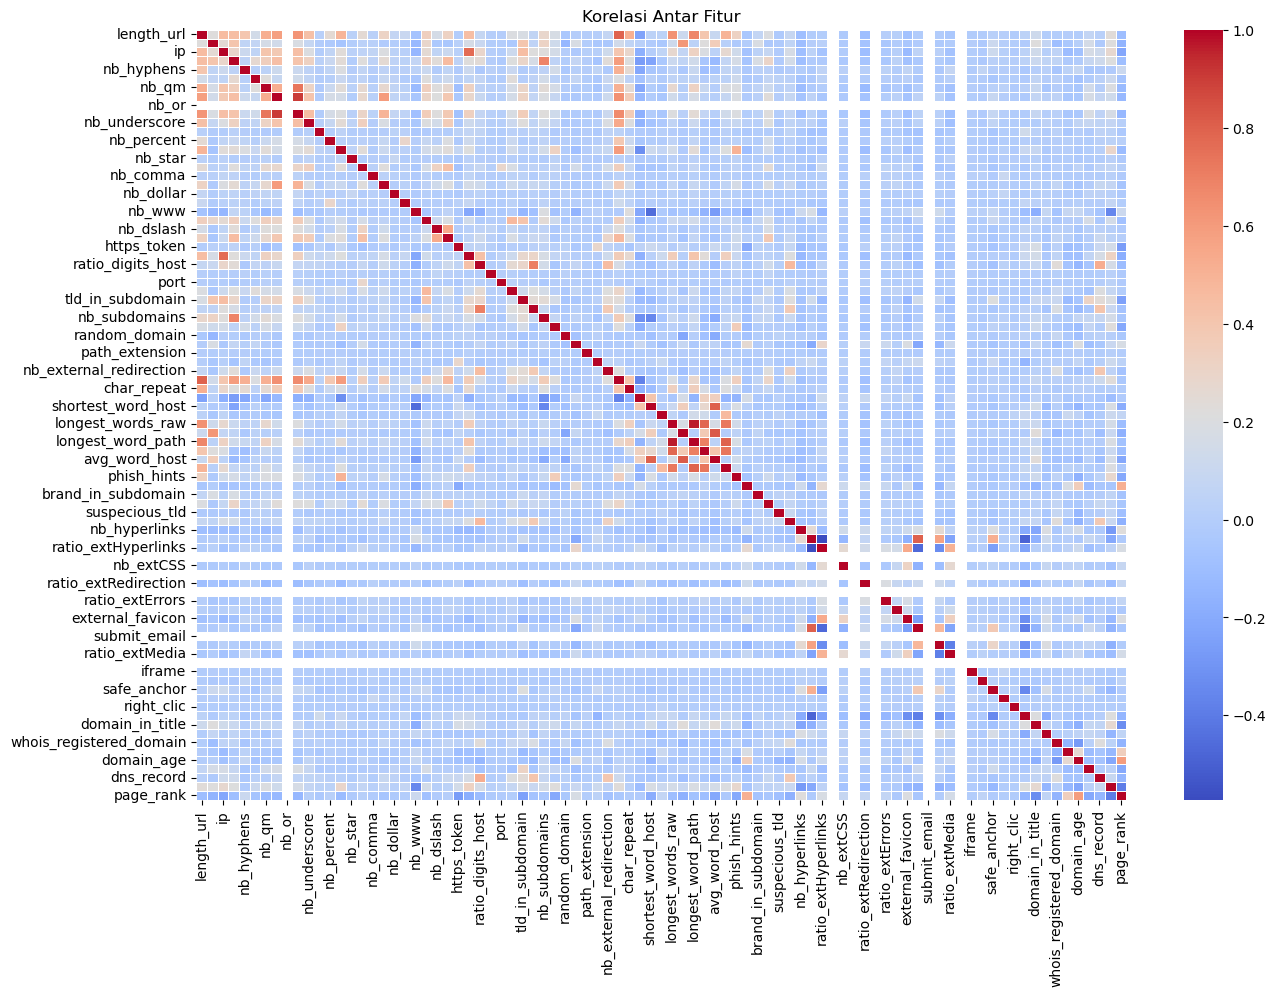

In [6]:
# Analisis Korelasi (Hanya untuk fitur numerik)
print("\n--- Heatmap Korelasi ---")
plt.figure(figsize=(15, 10))
# Memilih hanya kolom numerik untuk korelasi
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi Antar Fitur')
plt.show()

## **2. Data Preprocessing**

### **Data Selection**

In [7]:
file_path = r'D:\TUGAS AKHIR\phishing detector\dataset\dataset_phishing.csv'
df = pd.read_csv(file_path)

# List kolom yang tidak digunakan
kolom_yang_dihapus = [
    'nb_or', 
    'ratio_nullHyperlinks', 
    'ratio_intRedirection', 
    'ratio_intErrors', 
    'submit_email', 
    'sfh'
]

# Melakukan drop column
df_selected = df.drop(columns=kolom_yang_dihapus, errors='ignore')

# Menyimpan hasil ke file CSV baru
output_path = r'D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_selection.csv'
df_selected.to_csv(output_path, index=False)

# Menampilkan informasi dataset setelah seleksi
print("--- Tahap Data Selection ---")
print(f"Jumlah kolom awal : {df.shape[1]}")
print(f"Jumlah kolom dihapus : {len(kolom_yang_dihapus)}")
print(f"Jumlah kolom sekarang : {df_selected.shape[1]}")
print(f"File output  : {output_path}")

# Menampilkan 5 baris pertama dataset hasil seleksi
display(df_selected.head())

--- Tahap Data Selection ---
Jumlah kolom awal : 89
Jumlah kolom dihapus : 6
Jumlah kolom sekarang : 83
File output  : D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_selection.csv


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,3,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


### **Data Transformation**

In [8]:
# Membaca dataset awal
input_path = r'D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_selection.csv'
df_final = pd.read_csv(input_path)

# Transformasi: Mengubah 'status' menjadi 'label' dengan nilai numerik
if 'status' in df_final.columns:
    df_final['label'] = df_final['status'].map({'phishing': 1, 'legitimate': 0})
    df_final = df_final.drop(columns=['status'])

# Menyimpan ke file baru
output_path = r'D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_transformation.csv'
df_final.to_csv(output_path, index=False)

# Menampilkan Distribusi Kelas
print("Distribusi Kelas:", df_final['label'].value_counts().to_dict())

# Menampilkan jumlah baris dan kolom
jumlah_baris, jumlah_kolom = df_final.shape
print(f"Jumlah baris (data): {jumlah_baris}")
print(f"Jumlah kolom (fitur + label): {jumlah_kolom}")
print(f"File output  : {output_path}")

# Menampilkan sampel data
display(df_final[['url', 'label']].sample(5).style.hide())

Distribusi Kelas: {0: 5715, 1: 5715}
Jumlah baris (data): 11430
Jumlah kolom (fitur + label): 83
File output  : D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_transformation.csv


url,label
http://life-reboot.club/?email=abuse@cdpq.com,1
https://www.vvskupp.no/,0
http://www.arriendosencartagena.com/businessbusiness/doc/,1
https://www.flickr.com/groups/publicdomain/,0
http://timeless-uptime.sr/,1


### **Data Cleaning**

In [9]:
# 1. Membaca dataset hasil transformasi
input_path = r'D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_transformation.csv'
df_final = pd.read_csv(input_path)

# 2. Informasi awal dataset
baris_awal, kolom_awal = df_final.shape
print(f"Jumlah baris sebelum cleaning: {baris_awal}")
print(f"Jumlah kolom sebelum cleaning: {kolom_awal}")

# 3. Cek jumlah duplikat berdasarkan URL
jumlah_duplikat = df_final.duplicated(subset=['url']).sum()
print(f"Ditemukan {jumlah_duplikat} URL duplikat.")

# 4. Proses cleaning (hapus duplikat)
if jumlah_duplikat > 0:
    df_final = df_final.drop_duplicates(subset=['url'], keep='first').reset_index(drop=True)
    print("--- Duplikat berhasil dihapus ---")
else:
    print("--- Tidak ada duplikat yang perlu dihapus ---")

# 5. Verifikasi akhir dataset
baris_akhir, kolom_akhir = df_final.shape
print(f"Jumlah baris setelah cleaning: {baris_akhir}")
print(f"Jumlah kolom setelah cleaning: {kolom_akhir}")

# 6. Statistik kelas setelah cleaning
print("\nStatistik Kelas Setelah Cleaning:")
print(df_final['label'].value_counts())

# 7. Simpan ke file baru
output_path = r'D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv'
df_final.to_csv(output_path, index=False)

print(f"File output  : {output_path}")

Jumlah baris sebelum cleaning: 11430
Jumlah kolom sebelum cleaning: 83
Ditemukan 1 URL duplikat.
--- Duplikat berhasil dihapus ---
Jumlah baris setelah cleaning: 11429
Jumlah kolom setelah cleaning: 83

Statistik Kelas Setelah Cleaning:
label
0    5715
1    5714
Name: count, dtype: int64
File output  : D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv


### **Data Visualization**

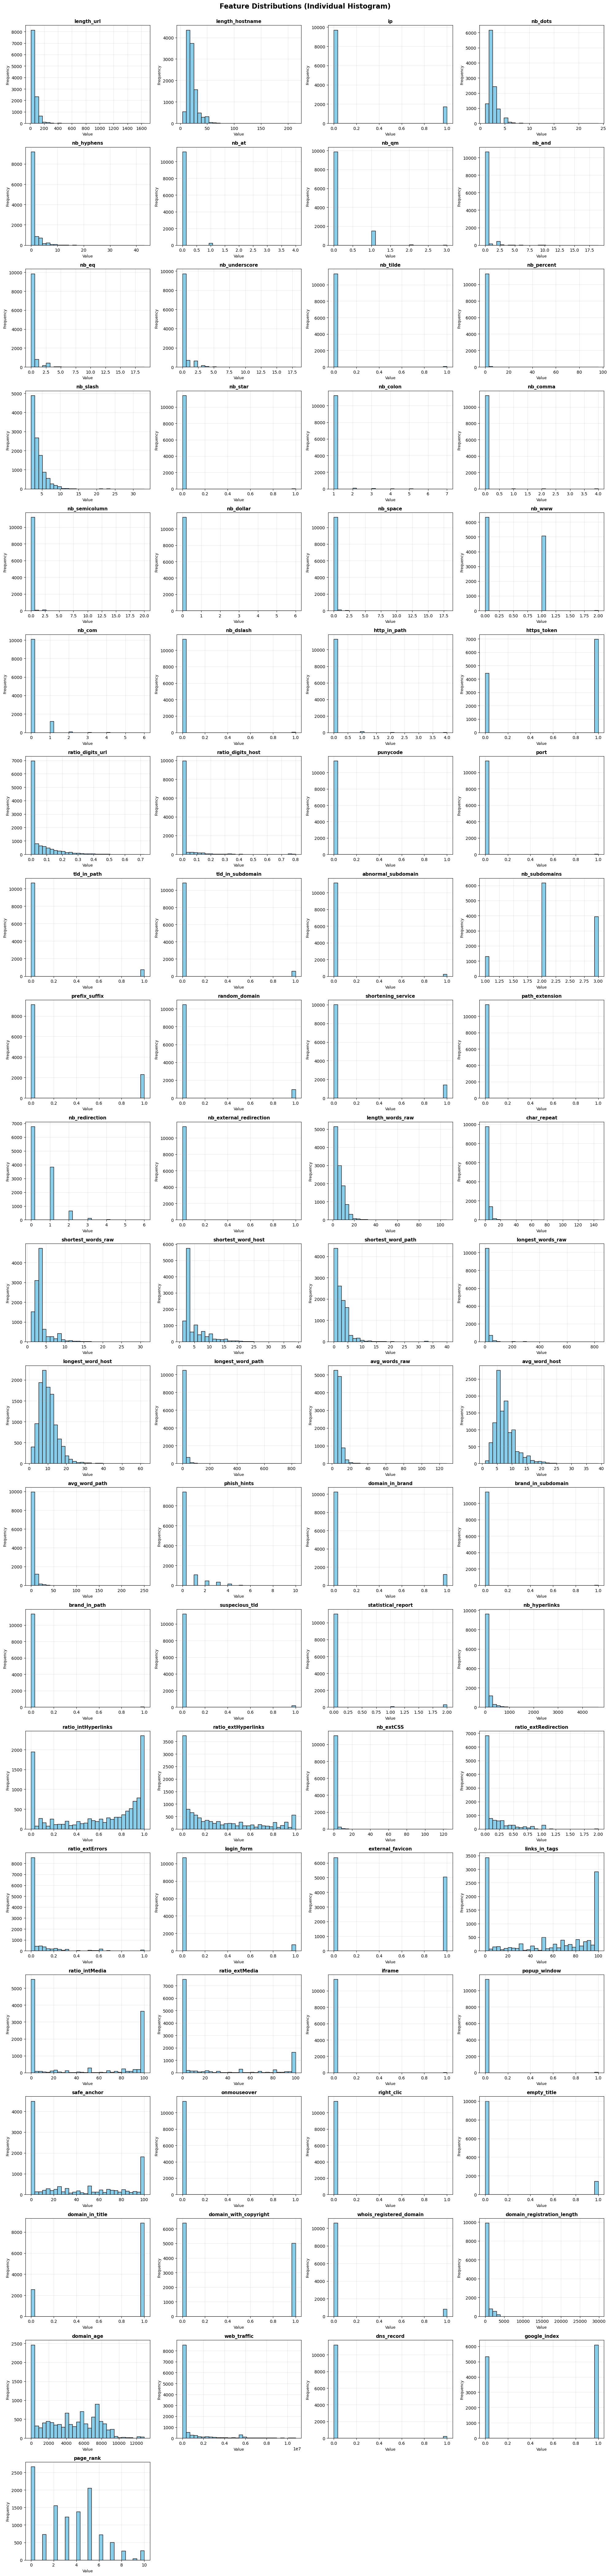

In [10]:
# 1. Membaca dataset hasil cleaning
input_path = r'D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv'
df_viz = pd.read_csv(input_path)

# 2. Visualisasi Distribusi Fitur Numerik (Setiap Fitur Individual)
numeric_cols = df_viz.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('label')  # Hapus kolom label dari visualisasi fitur

n_features = len(numeric_cols)
n_cols = 4  # Jumlah kolom subplot
n_rows = (n_features + n_cols - 1) // n_cols  # Hitung jumlah baris yang diperlukan

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()  # Flatten untuk memudahkan iterasi

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    df_viz[col].hist(bins=30, ax=ax, color="skyblue", edgecolor="black")
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.grid(True, alpha=0.3)

# Sembunyikan subplot yang kosong
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Feature Distributions (Individual Histogram)", y=1.00, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()